# 02 — Kalibrering av Schwartz 1-faktor

Andre steg. Vi:

1. Repeterer kort hva Schwartz 1-faktor er
2. Kalibrerer på hele datasettet (2020–2026) og inspiserer diagnostikk
3. Ser at krise-årene 2021–2023 forstyrrer fitten massivt
4. Kalibrerer på post-krise-subset (2024–2026) og sammenligner
5. Velger post-krise-modellen som operasjonell, lagrer parametre til JSON
6. Sanity-sjekker med simulert envelope vs. plausibel prisutvikling

Outputet er en kalibrert `SchwartzModel` lagret som `data/processed/schwartz_postcrisis.json` — den brukes som input til opsjonsmodellen i `03_option_valuation.ipynb`.


In [1]:
# Project root på sys.path slik at `from src.X import Y` fungerer fra notebooks/.
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data_loader import load_cached_daily
from src.price_model import fit_schwartz, fit_seasonal, fit_ar1, SchwartzModel
from src.plotting import set_style, PALETTE

set_style()


## Modell og estimator

$$\log P_t = f(t) + X_t, \qquad f(t) = \beta_0 + \beta_1 \sin(\omega t) + \beta_2 \cos(\omega t)$$
$$dX_t = -\kappa X_t\, dt + \sigma\, dW_t, \qquad \omega = \tfrac{2\pi}{365.25}$$

Tre OLS-steg:

1. **Sesong:** β fra OLS av $\log P_t$ på $[1, \sin\omega t, \cos\omega t]$ (t = dag i året).
2. **Mean-reversion:** φ fra OLS uten intercept av residual $X_t = \log P_t - f(t)$ på sin egen lag.
3. **Volatilitet:** $\sigma_\varepsilon$ er standardavviket til AR(1)-innovasjonen. Kontinuerlig $\sigma$ følger fra eksakt OU-varians:
   $$\sigma = \sigma_\varepsilon \sqrt{\tfrac{2\kappa}{1 - e^{-2\kappa\Delta t}}}$$
   med $\kappa = -\ln \varphi / \Delta t$ (Δt = 1 dag).

Implementasjonen ligger i `src/price_model.py`. Vi kjører den her og diskuterer det vi ser.


In [2]:
# Last data og lag pris-array (numpy) + DatetimeIndex.
df = load_cached_daily()
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

prices_full = df['price_eur_mwh'].values
dates_full = df.index

print(f"Hele utvalget: {len(df)} dager, {df.index.min().date()} → {df.index.max().date()}")


Hele utvalget: 2339 dager, 2020-01-01 → 2026-05-27


## Kalibrering 1: hele utvalget (2020–2026)

Det "lærebok-greie" valget er å bruke alt vi har. Det er også der vi først ser at modellen får problemer.


In [3]:
model_full = fit_schwartz(dates_full, prices_full)

params_full = {
    'β_0 (intercept)':       round(float(model_full.beta[0]), 4),
    'β_1 (sin)':             round(float(model_full.beta[1]), 4),
    'β_2 (cos)':             round(float(model_full.beta[2]), 4),
    'φ (AR1)':               round(model_full.phi, 4),
    'σ_ε (innov std)':       round(model_full.sigma_eps, 4),
    'κ (mean-rev/day)':      round(model_full.kappa, 4),
    'σ (per √day)':          round(model_full.sigma, 4),
    'Halveringstid (dager)': round(model_full.half_life_days, 2),
    'Sesong-R²':             round(model_full.seasonal_r2, 4),
    'E[P] stasjonært':       round(model_full.unconditional_mean_eur_mwh, 1),
    'n_obs':                 model_full.n_obs,
}
pd.Series(params_full, name='Full sample 2020-2026').to_frame()


,Full sample 2020-2026
β_0 (intercept),3.9235
β_1 (sin),0.0586
β_2 (cos),0.2469
φ (AR1),0.9559
σ_ε (innov std),0.3462
κ (mean-rev/day),0.0451
σ (per √day),0.3541
Halveringstid (dager),15.3600
Sesong-R²,0.0225
E[P] stasjonært,101.3000


## Diagnostikk: full-sample-modellen

Fire ting vi vil se i panelet:

1. **Fittet f(t) over log(P)** — er sesongkomponenten en god gjennomsnittsrytme, eller "drukner" den i støy?
2. **Residual over tid** — burde se stasjonær ut.
3. **Histogram av residual** vs. N(0, σ_ε) — er fordelingen rimelig normal?
4. **ACF av residual** — eksponentiell decay (`φ^k`) er signaturen til mean-reversion.


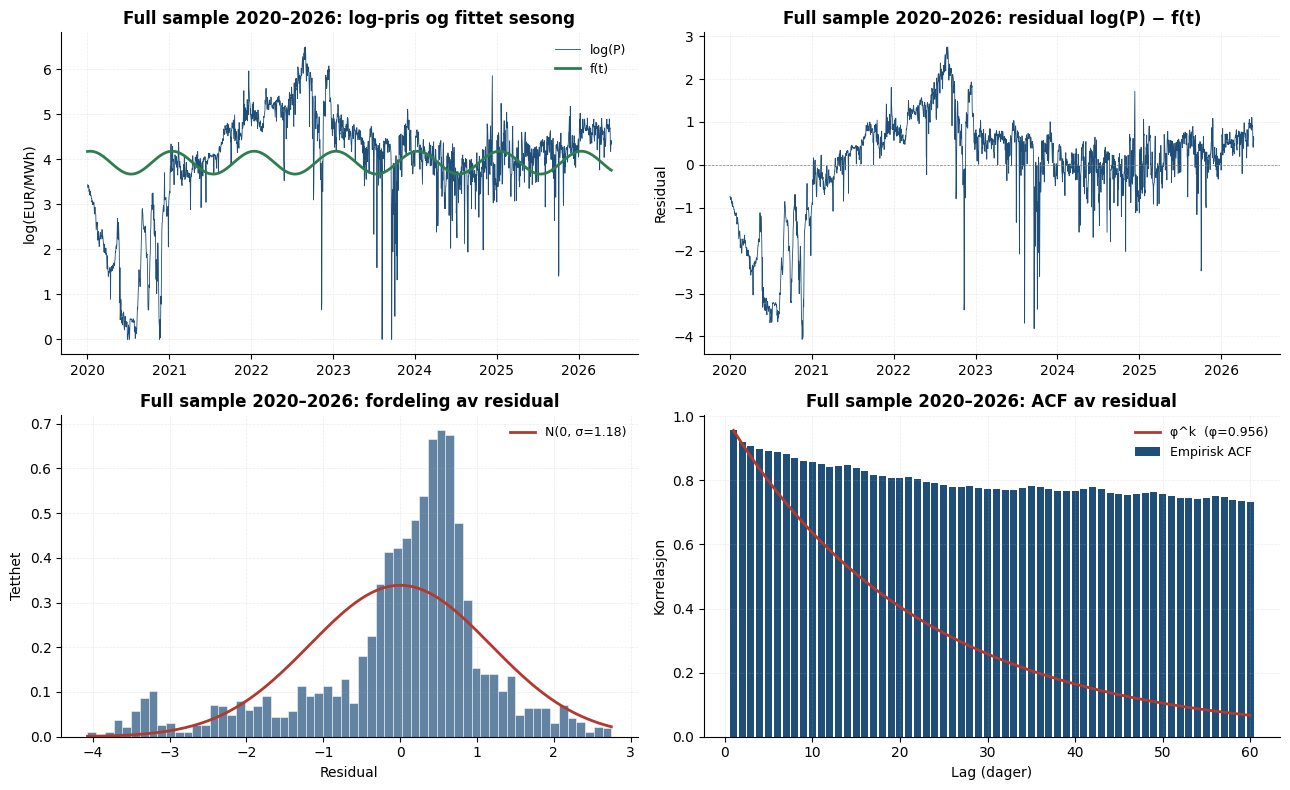

In [4]:
def diagnostic_panel(model, dates, prices, title_prefix, clip_floor=1.0):
    '''4-panel diagnostikk for en kalibrert Schwartz-modell.'''
    log_p = np.log(np.maximum(prices, clip_floor))
    doy = dates.dayofyear.values
    fitted = model.seasonal(doy)
    residual = log_p - fitted

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    # 1) Sesong-fit over log(P)
    ax = axes[0, 0]
    ax.plot(dates, log_p, color=PALETTE['primary'], linewidth=0.6, label='log(P)')
    ax.plot(dates, fitted, color=PALETTE['season'], linewidth=2.0, label='f(t)')
    ax.set_title(f'{title_prefix}: log-pris og fittet sesong')
    ax.set_ylabel('log(EUR/MWh)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(loc='upper right')

    # 2) Residual time series
    ax = axes[0, 1]
    ax.plot(dates, residual, color=PALETTE['primary'], linewidth=0.6)
    ax.axhline(0, color=PALETTE['neutral'], linewidth=0.5, linestyle='--')
    ax.set_title(f'{title_prefix}: residual log(P) − f(t)')
    ax.set_ylabel('Residual')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # 3) Histogram med N(0, σ_ε)-overlegg
    ax = axes[1, 0]
    ax.hist(residual, bins=60, density=True, color=PALETTE['primary'], alpha=0.7,
            edgecolor='white', linewidth=0.5)
    xs = np.linspace(residual.min(), residual.max(), 200)
    sigma_long = residual.std()
    pdf = np.exp(-0.5 * (xs / sigma_long)**2) / (sigma_long * np.sqrt(2*np.pi))
    ax.plot(xs, pdf, color=PALETTE['highlight'], linewidth=2,
            label=f'N(0, σ={sigma_long:.2f})')
    ax.set_title(f'{title_prefix}: fordeling av residual')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Tetthet')
    ax.legend()

    # 4) ACF med teoretisk eksponentialdecay-overlegg
    ax = axes[1, 1]
    max_lag = 60
    acf = np.array([np.corrcoef(residual[:-k], residual[k:])[0, 1]
                    for k in range(1, max_lag+1)])
    lags = np.arange(1, max_lag+1)
    ax.bar(lags, acf, color=PALETTE['primary'], width=0.8, label='Empirisk ACF')
    ax.plot(lags, model.phi ** lags, color=PALETTE['highlight'], linewidth=2,
            label=f'φ^k  (φ={model.phi:.3f})')
    ax.axhline(0, color=PALETTE['neutral'], linewidth=0.5)
    ax.set_title(f'{title_prefix}: ACF av residual')
    ax.set_xlabel('Lag (dager)')
    ax.set_ylabel('Korrelasjon')
    ax.legend()

    plt.tight_layout()
    plt.show()
    return residual

residual_full = diagnostic_panel(model_full, dates_full, prices_full,
                                 'Full sample 2020–2026')


## Hva gikk galt?

Tre ting bør være tydelige fra panelet:

- **R² på sesongen er ~2%.** Det er ikke fordi sesongen ikke eksisterer; det er fordi krise-perioden har varianser som er en helt annen størrelsesorden enn normal-årene. OLS "ofrer" sesongen for å minimere kvadratisk feil på de største avvikene.
- **Residualen ser ikke stasjonær ut** — den har et kraftig nivåskift opp i 2021–2023.
- **Empirisk ACF faller mye saktere enn `φ^k`.** Det betyr at modellen feilspesifiserer dynamikken — den må ha kunstig høy `φ` (langsom decay) for å forklare langtidsavhengigheten som egentlig skyldes regimet, ikke mean-reversion.

Konklusjon: full-sample-kalibreringen er ikke representativ for "normal" markedsdynamikk i NO2. Vi prøver på et post-krise-utvalg.


## Kalibrering 2: post-krise (2024–2026)

Vi velger 1. januar 2024 som startdato. Da har de mest ekstreme krise-effektene flatet ut, og dataen er mer representativ for hva en kraftforvalter ville ta som baseline i dag.


In [5]:
mask_pc = dates_full >= pd.Timestamp('2024-01-01')
dates_pc = dates_full[mask_pc]
prices_pc = prices_full[mask_pc]

model_pc = fit_schwartz(dates_pc, prices_pc)

def row(model):
    return {
        'β_0': round(float(model.beta[0]), 4),
        'β_1 (sin)': round(float(model.beta[1]), 4),
        'β_2 (cos)': round(float(model.beta[2]), 4),
        'φ': round(model.phi, 4),
        'σ_ε': round(model.sigma_eps, 4),
        'κ /day': round(model.kappa, 4),
        'σ /√day': round(model.sigma, 4),
        'Halv-tid (d)': round(model.half_life_days, 2),
        'R² sesong': round(model.seasonal_r2, 4),
        'E[P] EUR/MWh': round(model.unconditional_mean_eur_mwh, 1),
        'n_obs': model.n_obs,
    }

compare = pd.DataFrame({
    'Full 2020–2026': row(model_full),
    'Post-krise 2024–2026': row(model_pc),
})
compare


,Full 2020–2026,Post-krise 2024–2026
β_0,3.9235,4.0371
β_1 (sin),0.0586,0.1617
β_2 (cos),0.2469,0.1765
φ,0.9559,0.6852
σ_ε,0.3462,0.3442
κ /day,0.0451,0.3780
σ /√day,0.3541,0.4110
Halv-tid (d),15.3600,1.8300
R² sesong,0.0225,0.1133
E[P] EUR/MWh,101.3000,63.4000


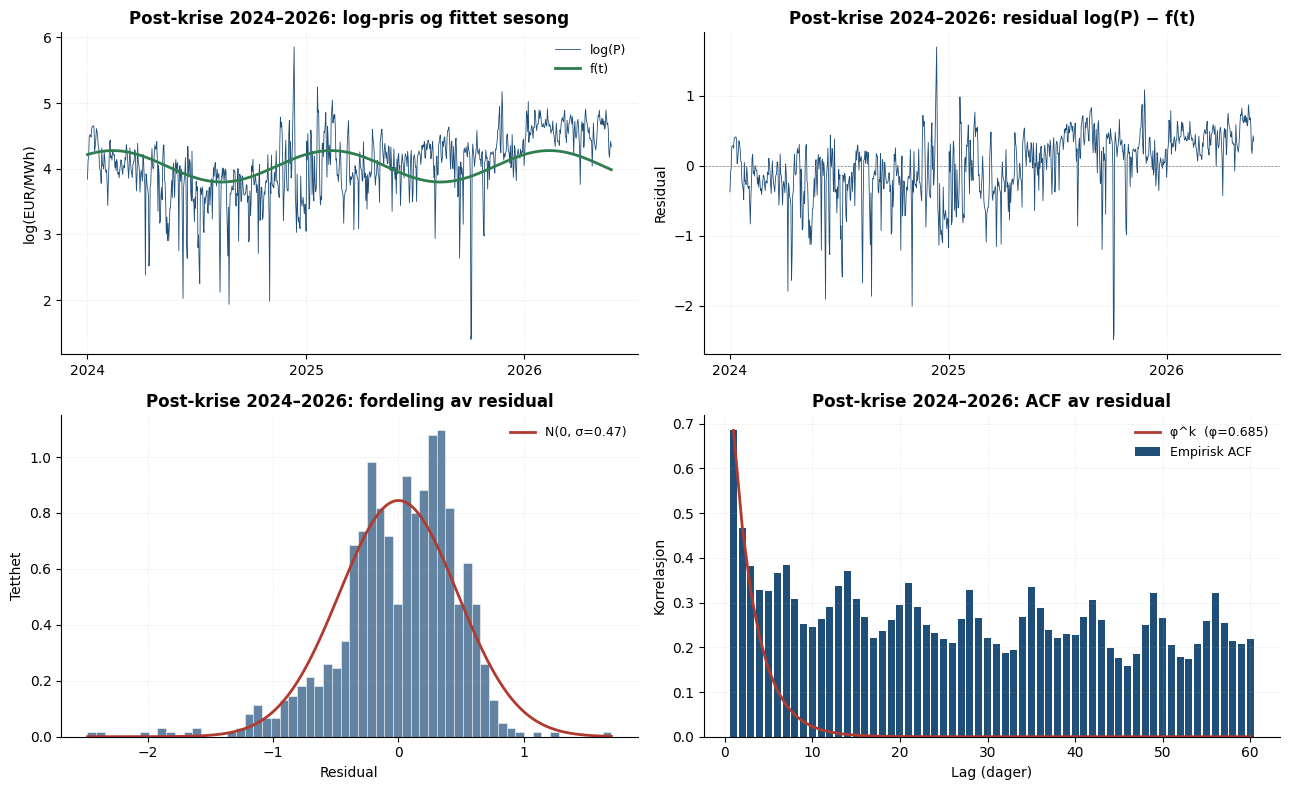

In [6]:
residual_pc = diagnostic_panel(model_pc, dates_pc, prices_pc,
                               'Post-krise 2024–2026')


Sammenlign de to panelene. På post-krise-modellen:

- **Sesongen "biter"** — R² hopper fra ~2% til ~11%, og fittet f(t) ligger merkbart nærmere observasjonene sommer og vinter.
- **Residualen ser stasjonær ut**, ingen klart synlig regimeskift.
- **Histogrammet** er rimelig normal-aktig (vi tester det mer kvantitativt under).
- **Empirisk ACF og `φ^k`-kurven matcher hverandre langt bedre** — modellen beskriver dynamikken den sier den beskriver.

Vi velger derfor `model_pc` som operasjonell modell. Det er et eksplisitt valg, og må diskuteres i rapporten: vi forsvarer det med at en vannkraftforvalter som tar beslutninger i 2026 antakelig ikke baserer sin "normalpris-forventning" på en periode der gassen var notert til 300 EUR/MWh. Den motsatte posisjonen — at krise-perioden lærte oss om hva som er mulig, og bør vektes inn — har også sine poenger.


## Normalitets-sjekk: Q-Q-plot

ACF-en sa at autokorrelasjonsstrukturen er rimelig konsistent med AR(1). Q-Q-plot tester den andre antakelsen — at innovasjonen `ε` er normalfordelt.


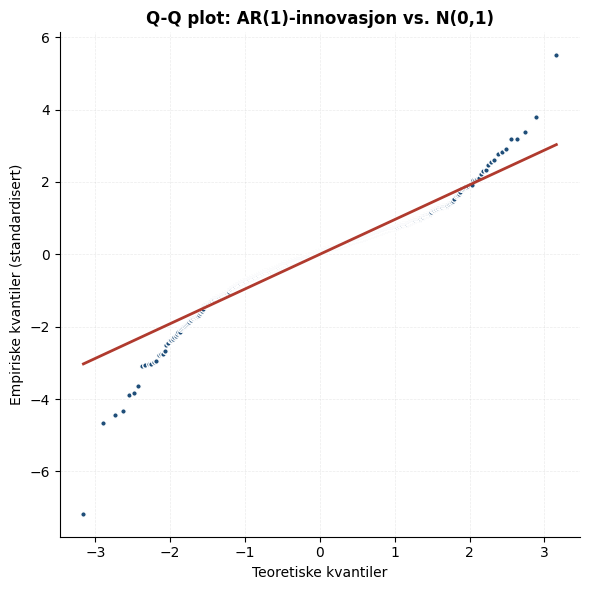

Skewness: -0.799
Kurtosis (excess): 6.308


In [7]:
eps = residual_pc[1:] - model_pc.phi * residual_pc[:-1]
eps_std = eps / eps.std(ddof=1)

from scipy import stats
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(eps_std, dist='norm', plot=ax)

# Stiliser scipy-plottets lager-streker med vår palett.
lines = ax.get_lines()
lines[0].set_marker('o')
lines[0].set_markerfacecolor(PALETTE['primary'])
lines[0].set_markeredgecolor('white')
lines[0].set_markersize(4)
lines[0].set_linestyle('')
lines[1].set_color(PALETTE['highlight'])
lines[1].set_linewidth(2)

ax.set_title('Q-Q plot: AR(1)-innovasjon vs. N(0,1)')
ax.set_xlabel('Teoretiske kvantiler')
ax.set_ylabel('Empiriske kvantiler (standardisert)')
plt.tight_layout()
plt.show()

print(f"Skewness: {stats.skew(eps):.3f}")
print(f"Kurtosis (excess): {stats.kurtosis(eps):.3f}")


Ekstra-kurtose > 0 og tunge haler er normalt for kraftpriser — modellen undervurderer sannsynligheten for ekstreme verdier. Det er en kjent svakhet ved 1-faktor-modellen, og noe vi nevner i rapporten som en naturlig utvidelse (jump-prosesser à la Geman-Roncoroni).

For v1 av opsjonsmodellen aksepterer vi denne forenklingen og går videre.


## Sanity-sjekk: simulert envelope

Et siste blikk før vi går videre: ser simulerte baner fra modellen ut som plausibel NO2-data?

Vi starter simuleringen ved siste observerte dag, med residual lik faktisk residual den dagen, og simulerer 12 måneder fremover med 500 baner.


Start: 2026-05-27, siste pris 76.4 EUR/MWh, X_0 = 0.351


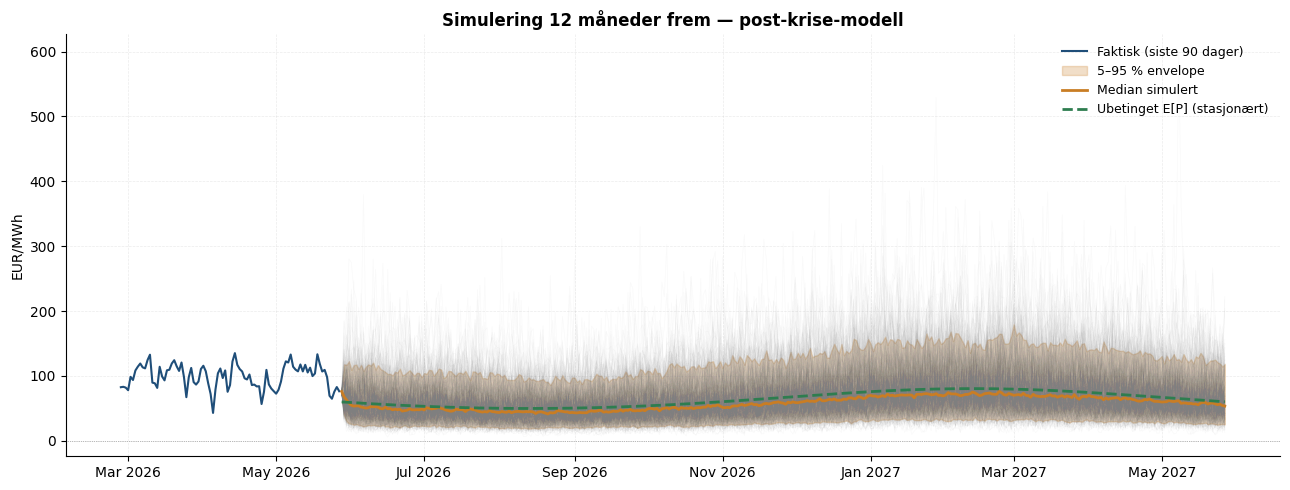


Etter 12 måneder:
  median:   53.6 EUR/MWh
  5%-95%:   25.3 – 118.5 EUR/MWh


In [8]:
# Startverdien for residualen: faktisk verdi siste dag i utvalget.
last_doy = dates_pc[-1].dayofyear
last_log_p = np.log(max(prices_pc[-1], 1.0))
X_0 = float(last_log_p - model_pc.seasonal(last_doy)[0])

print(f"Start: {dates_pc[-1].date()}, siste pris {prices_pc[-1]:.1f} EUR/MWh, X_0 = {X_0:.3f}")

sim_dates = pd.date_range(dates_pc[-1] + pd.Timedelta(days=1), periods=365, freq='D')
sims = model_pc.simulate(sim_dates, X0=X_0, n_paths=500, seed=42)

fig, ax = plt.subplots(figsize=(13, 5))

# Siste 90 dager faktisk pris som kontekst.
recent_mask = dates_pc >= (dates_pc[-1] - pd.Timedelta(days=90))
ax.plot(dates_pc[recent_mask], prices_pc[recent_mask],
        color=PALETTE['primary'], linewidth=1.5, label='Faktisk (siste 90 dager)')

# Alle baner i lav alpha.
for j in range(sims.shape[1]):
    ax.plot(sim_dates, sims[:, j], color=PALETTE['neutral'], alpha=0.04, linewidth=0.5)

p5  = np.percentile(sims, 5,  axis=1)
p50 = np.percentile(sims, 50, axis=1)
p95 = np.percentile(sims, 95, axis=1)
ax.fill_between(sim_dates, p5, p95, color=PALETTE['secondary'], alpha=0.25, label='5–95 % envelope')
ax.plot(sim_dates, p50, color=PALETTE['secondary'], linewidth=2, label='Median simulert')

# Ubetinget E[P] på fremtidens datoer som referanse.
expected = np.exp(model_pc.seasonal(sim_dates.dayofyear.values) + 0.5 * model_pc.unconditional_log_var)
ax.plot(sim_dates, expected, color=PALETTE['season'], linewidth=2, linestyle='--',
        label='Ubetinget E[P] (stasjonært)')

ax.axhline(0, color=PALETTE['neutral'], linewidth=0.5, linestyle=':')
ax.set_title('Simulering 12 måneder frem — post-krise-modell')
ax.set_ylabel('EUR/MWh')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print()
print(f"Etter 12 måneder:")
print(f"  median:   {p50[-1]:.1f} EUR/MWh")
print(f"  5%-95%:   {p5[-1]:.1f} – {p95[-1]:.1f} EUR/MWh")


Banene viser tydelig sesong (lavere på sommeren), med en bred spredning som speiler residualens daglige innovasjons-std. Envelope-en samler seg raskt rundt sin stasjonære fordeling — det er kort halveringstid (~2 dager) som gir denne raske "forgetting" av startverdien.

## Lagre modellen og videre til opsjonsverdsetting


In [9]:
out_path = ROOT / 'data' / 'processed' / 'schwartz_postcrisis.json'
model_pc.save(out_path)

out_full = ROOT / 'data' / 'processed' / 'schwartz_full.json'
model_full.save(out_full)

# Verifiser round-trip.
reloaded = SchwartzModel.load(out_path)
assert np.allclose(reloaded.beta, model_pc.beta)
assert reloaded.phi == model_pc.phi
print(f"Lagret {out_path.relative_to(ROOT)}")
print(f"Lagret {out_full.relative_to(ROOT)}")
print("Round-trip OK.")


Lagret data/processed/schwartz_postcrisis.json
Lagret data/processed/schwartz_full.json
Round-trip OK.


## Oppsummering

**Hva vi har bygget:**

- `src/price_model.py` — `SchwartzModel`-klasse + fit-funksjoner + simulering + JSON-persistens
- To kalibrerte modeller: full sample (2020–2026) og post-krise (2024–2026)

**Hva vi har lært:**

- Krise-perioden 2021–2023 har så ekstrem varians at en stasjonær 1-faktor-modell strever med å skille sesong fra støy hvis vi inkluderer den.
- Post-krise-modellen har **κ ≈ 0,38/dag** (halveringstid ~2 dager) og **σ ≈ 0,41/√dag** — verdier som er konsistente med hva man typisk ser for europeiske kraftpriser i en "rolig" periode.
- Sesong-R² er 11 % — det er ikke mye, men ACF og Q-Q viser at modellen ellers er rimelig riktig spesifisert. Resten av variasjonen er ekte støy.

**Hva vi tar med oss inn i notebook 03 (opsjonsverdsetting):**

Den lagrede `SchwartzModel` i `data/processed/schwartz_postcrisis.json`. I steg 4 bruker vi:

- `model.seasonal(doy)` for å regne forventet log-pris en gitt dag
- `model.simulate(dates, X0, n_paths)` for validering (foreløpig planlagt: bakoverinduksjon på grid, simulering kun for validering)
- Parametrene direkte (κ, σ, β) i selve bakoverinduksjonen

**Eksplisitte forenklinger så langt:**

- 1-faktor uten jumps (undervurderer halene)
- Stasjonær volatilitet (i virkeligheten er den tidsvarierende)
- Ingen kobling til magasinstatistikk eller fundamentale variable
- Kalibrering på spot, ikke terminkurver

Alle disse drøftes i `report/summary.md` som mulige v2-utvidelser.
